In [2]:
import numpy as np 
import pandas as pd

In [20]:
# Load data and perform SVD
data = pd.read_csv('Math_232_Data/processed_data.csv')
data = data.iloc[:, 1:] # remove the timestamp column
data.head()

,Value_1,Value_2,Value_3,Value_4,Value_5,Value_6,Value_7,Value_8,Value_9,Value_10,...,Value_71,Value_72,Value_73,Value_74,Value_75,Value_76,Value_77,Value_78,Value_79,Value_80
0,-101.6,-100.200000,-101.80,-102.200000,-102.2,-102.200000,-102.000000,-101.800000,-99.6,-101.60,...,-99.600000,-100.600000,-100.4,-100.4,-99.000000,-100.000000,-100.6,-99.8,-99.8,-100.0
1,-101.6,-100.100000,-101.80,-102.300000,-102.2,-102.200000,-101.900000,-101.800000,-99.6,-101.60,...,-99.600000,-100.500000,-100.4,-100.4,-99.100000,-100.000000,-100.6,-99.8,-99.8,-100.0
2,-101.6,-100.133333,-101.80,-102.333333,-102.2,-102.266667,-101.866667,-101.733333,-99.6,-101.60,...,-99.666667,-100.533333,-100.4,-100.4,-99.066667,-99.933333,-100.6,-99.8,-99.8,-100.0
3,-101.6,-100.150000,-101.80,-102.350000,-102.2,-102.300000,-101.850000,-101.750000,-99.6,-101.55,...,-99.650000,-100.550000,-100.4,-100.4,-99.100000,-99.900000,-100.6,-99.8,-99.8,-100.0
4,-101.6,-100.160000,-101.84,-102.320000,-102.2,-102.280000,-101.840000,-101.760000,-99.6,-101.56,...,-99.640000,-100.560000,-100.4,-100.4,-99.080000,-99.880000,-100.6,-99.8,-99.8,-100.0


In [21]:
print(data.shape)

(3115, 80)


In [30]:
X = data.values

X_centered = X - np.mean(X, axis=0, keepdims=True)
X_std      = X_centered / np.std(X_centered, axis=0, ddof=1)
B = X_std

U, s, Vt = np.linalg.svd(B, full_matrices=False)

print(f"U shape: {U.shape}")
print(f"s shape: {s.shape}")
print(f"Vt shape: {Vt.shape}")

U shape: (3115, 80)
s shape: (80,)
Vt shape: (80, 80)


In [23]:
B

array([[-4.53773084, -4.53467806, -4.52264421, ..., -4.50393799,
        -4.52227892, -4.53595183],
       [-4.53773084, -4.52994521, -4.52264421, ..., -4.50393799,
        -4.52227892, -4.53595183],
       [-4.53773084, -4.53152283, -4.52264421, ..., -4.50393799,
        -4.52227892, -4.53595183],
       ...,
       [ 0.22833902,  0.19816725,  0.14692244, ...,  0.09642773,
         0.15525653,  0.2320862 ],
       [ 0.22833902,  0.19816725,  0.14692244, ...,  0.09642773,
         0.15525653,  0.2301744 ],
       [ 0.22645296,  0.19816725,  0.14692244, ...,  0.09642773,
         0.15525653,  0.2301744 ]])

Now we can visualize the covariance matrix $BB^T$

In [9]:
import matplotlib.pyplot as plt
import seaborn as sns

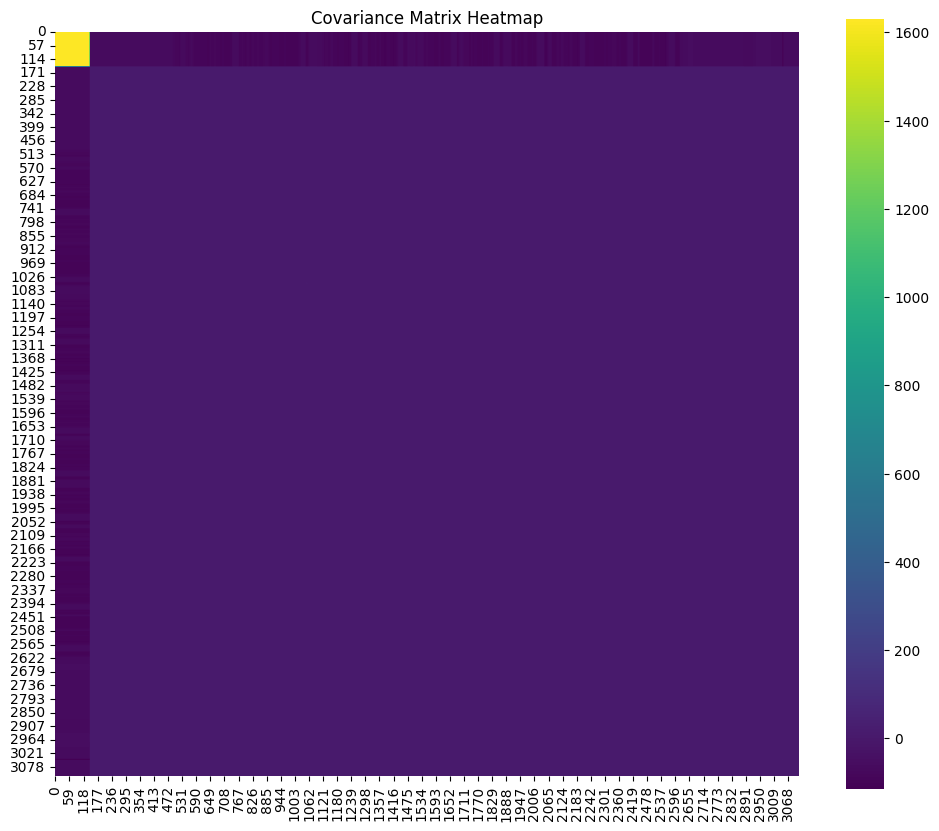

Shape of covariance matrix: (3115, 3115)

Maximum value: 1630.5682419776062
Minimum value: -114.37877060349162
Mean value: -2.964717134465883e-16


In [32]:
covariance_matrix = B @ B.T

plt.figure(figsize=(12, 10))
sns.heatmap(covariance_matrix, 
            cmap='viridis',
            square=True)
plt.title('Covariance Matrix Heatmap')
plt.show()

# Print some basic statistics about the covariance matrix
print("Shape of covariance matrix:", covariance_matrix.shape)
print("\nMaximum value:", np.max(covariance_matrix))
print("Minimum value:", np.min(covariance_matrix))
print("Mean value:", np.mean(covariance_matrix))

# PCA

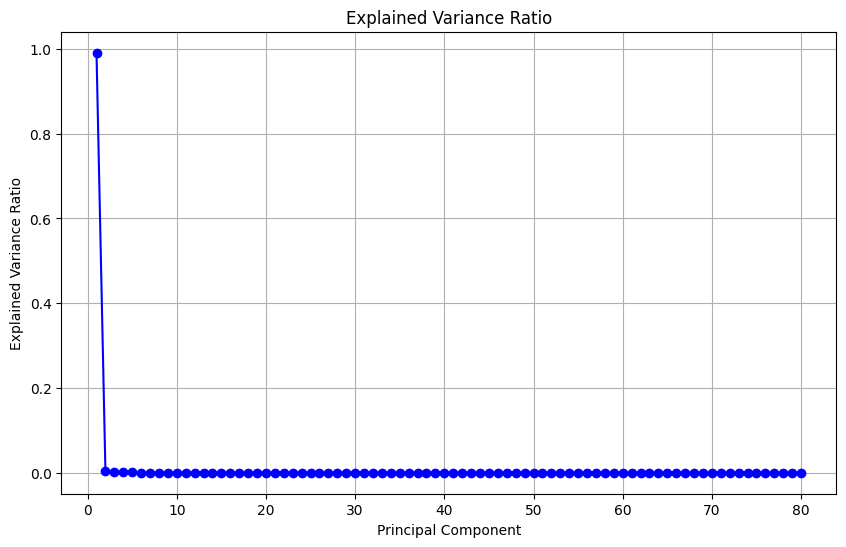

In [25]:
# Calculate the principal components (PCs)
# The columns of Vt are the right singular vectors (eigenvectors of B^T B)
PCs = Vt.T  # This gives us the principal components

# Calculate the scores (projections of the data onto the PCs)
scores = B @ PCs

# Calculate the explained variance ratio
total_var = np.sum(s**2)
explained_var_ratio = (s**2) / total_var

# Plot the explained variance ratio
plt.figure(figsize=(10, 6))
plt.plot(range(1, len(explained_var_ratio) + 1), explained_var_ratio, 'bo-')
plt.title('Explained Variance Ratio')
plt.xlabel('Principal Component')
plt.ylabel('Explained Variance Ratio')
plt.grid(True)
plt.show()

In [26]:
# Print the cumulative explained variance
cumulative_var = np.cumsum(explained_var_ratio)
print("Cumulative explained variance ratio:")
for i, var in enumerate(cumulative_var):
    print(f"PC{i+1}: {var:.4f}")

Cumulative explained variance ratio:
PC1: 0.9911
PC2: 0.9946
PC3: 0.9963
PC4: 0.9973
PC5: 0.9979
PC6: 0.9984
PC7: 0.9989
PC8: 0.9991
PC9: 0.9993
PC10: 0.9994
PC11: 0.9995
PC12: 0.9996
PC13: 0.9996
PC14: 0.9997
PC15: 0.9997
PC16: 0.9997
PC17: 0.9998
PC18: 0.9998
PC19: 0.9998
PC20: 0.9998
PC21: 0.9999
PC22: 0.9999
PC23: 0.9999
PC24: 0.9999
PC25: 0.9999
PC26: 0.9999
PC27: 0.9999
PC28: 0.9999
PC29: 0.9999
PC30: 1.0000
PC31: 1.0000
PC32: 1.0000
PC33: 1.0000
PC34: 1.0000
PC35: 1.0000
PC36: 1.0000
PC37: 1.0000
PC38: 1.0000
PC39: 1.0000
PC40: 1.0000
PC41: 1.0000
PC42: 1.0000
PC43: 1.0000
PC44: 1.0000
PC45: 1.0000
PC46: 1.0000
PC47: 1.0000
PC48: 1.0000
PC49: 1.0000
PC50: 1.0000
PC51: 1.0000
PC52: 1.0000
PC53: 1.0000
PC54: 1.0000
PC55: 1.0000
PC56: 1.0000
PC57: 1.0000
PC58: 1.0000
PC59: 1.0000
PC60: 1.0000
PC61: 1.0000
PC62: 1.0000
PC63: 1.0000
PC64: 1.0000
PC65: 1.0000
PC66: 1.0000
PC67: 1.0000
PC68: 1.0000
PC69: 1.0000
PC70: 1.0000
PC71: 1.0000
PC72: 1.0000
PC73: 1.0000
PC74: 1.0000
PC75: 1.00

Scree plot suggests we should use around just one or two PCs. Cumulative variance for the first PC is > 99%, which is very good.

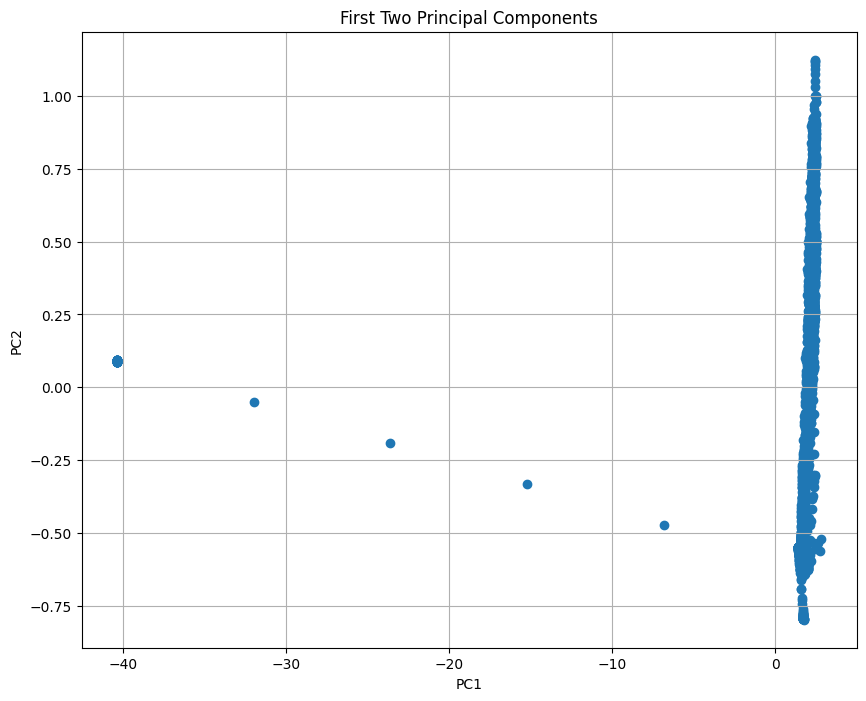

In [27]:
# Plot the first two principal components
plt.figure(figsize=(10, 8))
plt.scatter(scores[:, 0], scores[:, 1])
plt.title('First Two Principal Components')
plt.xlabel('PC1')
plt.ylabel('PC2')
plt.grid(True)
plt.show()

It seems the data is not very well separated ):

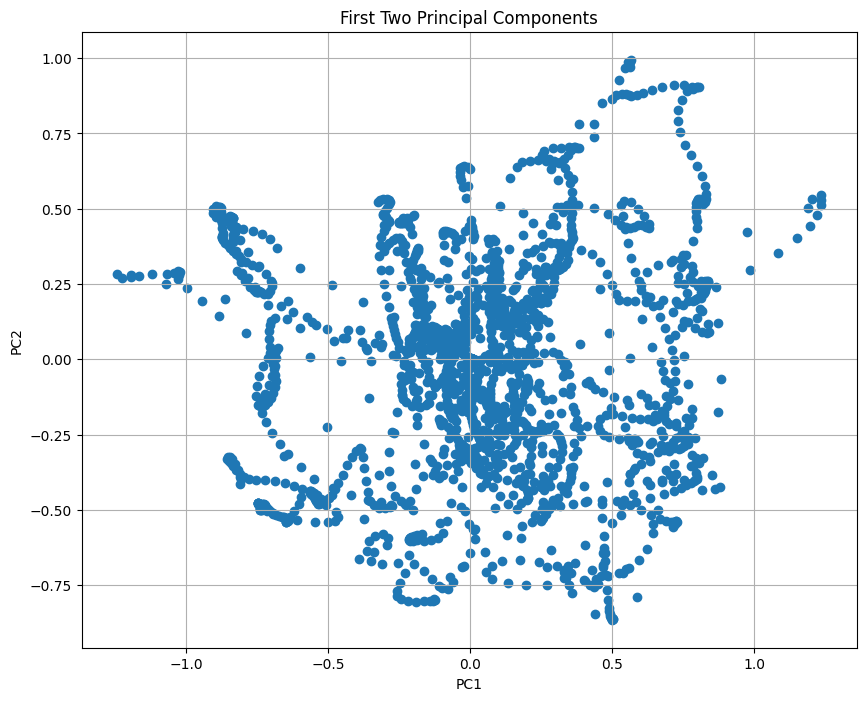

In [29]:
plt.figure(figsize=(10, 8))
plt.scatter(scores[:, 2], scores[:, 3])
plt.title('First Two Principal Components')
plt.xlabel('PC1')
plt.ylabel('PC2')
plt.grid(True)
plt.show()